In [1]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import numpy as np
import torch
import tensorly as tl
from tensorly.decomposition import parafac
import sparse
import pickle
import os
import numpy.random as rn
import scipy.stats as st
from tensorly.cp_tensor import CPTensor

from bptf import BPTF as BPTF
import bptf

<IPython.core.display.Javascript object>

Kernel is restarting...


# Helper functions

In [2]:
def generate(shp=(30, 30, 20, 10), K=5, alpha=0.1, beta=0.1):
    """Generate a count tensor from the BPTF model.

    PARAMS:
    shp -- (tuple) shape of the generated count tensor
    K -- (int) number of latent components
    alpha -- (float) shape parameter of gamma prior over factors
    beta -- (float) rate parameter of gamma prior over factors

    RETURNS:
    Mu -- (np.ndarray) true Poisson rates
    Y -- (np.ndarray) generated count tensor
    """
    Theta_DK_M = [rn.gamma(alpha, 1./beta, size=(D, K)) for D in shp]
    Mu = tl.cp_to_tensor(CPTensor((None, Theta_DK_M)))
    assert Mu.shape == shp
    Y = rn.poisson(Mu)
    return Mu, Y

# Generate data

In [3]:
use_existing_data = True

rn.seed(100)

if use_existing_data:
    assert os.path.exists('sptensor.pkl'), 'No such file.'
    with open('sptensor.pkl', 'rb') as f:
        data = pickle.load(f)
    data = data[:, :, :, :24, :]
    data = sparse.COO(data)
else:
    data = generate(shp=(200, 200, 20, 24, 3), K=10)[1]
    data = sparse.COO(data)

# Fit with BPTF

In [4]:
n_components = 50
max_iter = 500
mask = None
device = 'cuda'
tol = 1e-10

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=False, missing_val=1, tol=tol)

  0%|                                                                                                      | 0/500 [00:00<?, ?it/s]

Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 0]  min uttkrp_DK = 3.165e+05
[mode 0]  min new rate = 3.165e+05   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 1]  min uttkrp_DK = 8.658e+02
[mode 1]  min new rate = 8.659e+02   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 2]  min uttkrp_DK = 1.092e+04
[mode 2]  min new rate = 1.092e+04   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 3]  min uttkrp_DK = 7.429e+03
[mode 3]  min new rate = 7.429e+03   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


...

Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 3]  min uttkrp_DK = 3.817e+03
[mode 3]  min new rate = 3.817e+03   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 4]  min uttkrp_DK = 2.852e+04
[mode 4]  min new rate = 2.852e+04   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


100%|████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [47:06<00:00,  5.64s/it]

100%|████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [47:06<00:00,  5.65s/it]

BPTF(data_shape=(280, 280, 20, 24, 3), n_components=50)

# Fit with own BPTF_torch

In [5]:
from own_implementation import BPTF as BPTF_torch

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-6011518489.081111, 18439152.84529491, 18858602.95565969, 20579192.94503875, 24408545.649198804, 29206710.922372006, 33262583.548636753, 35903776.823871985, 37360750.777943484, 38196672.76783513, 38702800.63959554, 39022777.075267, 39245058.44567811, 39410475.74099728, 39541993.546370715, 39653927.997770295, 39744394.36951838, 39813342.8071353, 39870482.59159688, 39919645.405387975, 39962176.43406805, 39999644.8502554, 40033344.68384651, 40063228.52640199, 40089067.78178024, 40110685.66421571, 40128694.35565014, 40144387.49428379, 40158432.98041962, 40171146.23954355, 40182763.53439147, 40193461.436375305, 40203364.53035559, 40212574.185808696, 40221185.44455685, 40229373.00325287, 40237073.39722851, 40244253.61891357, 40251024.724160954, 40257411.367263325, 40263440.68351351, 40269141.52606687, 40274553.60169137, 40279696.20421351, 40284617.25822937, 40289339.269947544, 40293859.5565708, 40

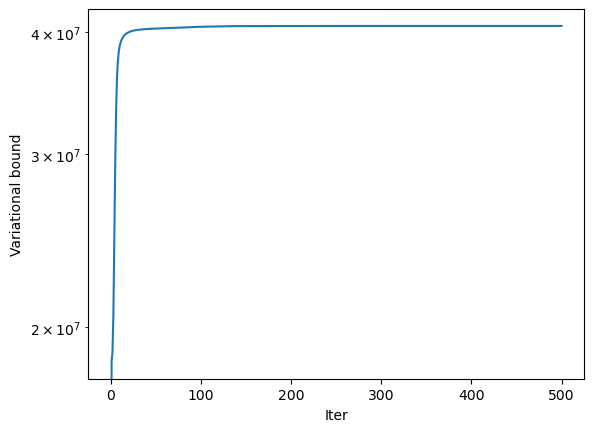

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 24, 3]), device='cuda',
     n_components=50)

In [6]:
data = torch.tensor(data.todense(), dtype = torch.float64, device=device)
BPTF_model_torch = BPTF_torch(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model_torch.fit(data, mask = None, max_iter = max_iter, verbose=False, tol=tol)

# Check similarity

In [7]:
BPTF_G_DK_M = [torch.tensor(factor_matrix, dtype=torch.float64, device=device) for factor_matrix in BPTF_model.G_DK_M]
fro_norm_rel_diff = torch.norm(BPTF_model_torch.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), 'fro') / torch.norm(tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), 'fro')
print(f'Frobenius norm relative difference: {fro_norm_rel_diff}')

threshold = 0.05
diff = torch.abs(BPTF_model_torch.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)))
prop_exceed = (diff > threshold).sum().item() / diff.numel()
print(f'Proportion of elements with difference greater than {threshold} = {prop_exceed}')

Frobenius norm relative difference: 0.21443246283254344
Proportion of elements with difference greater than 0.05 = 0.04098767892573696


tensor(0.9208, device='cuda:0') tensor(0.1592, device='cuda:0') tensor(4825.8305, device='cuda:0')


tensor([192631, 184775, 188966, 201881, 214454, 215703, 181415, 190474, 182783,
        191780, 188951, 167489, 194660, 198776, 195652, 200427, 205984, 193513,
        193188, 176555, 192294, 200461, 191696, 182837], device='cuda:0')


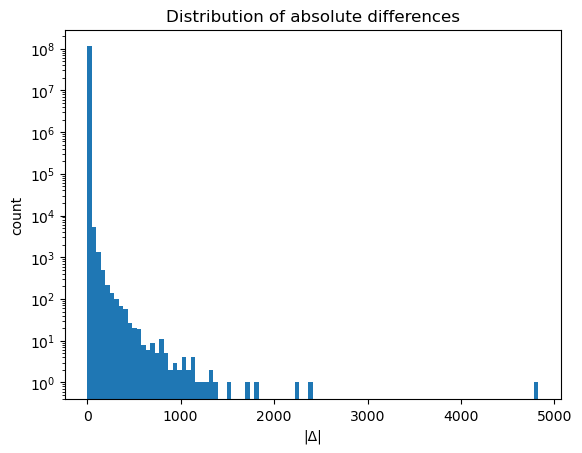

In [8]:
# 1) How big are the large errors?
big = diff[diff > 0.05]
print(big.mean(), big.median(), big.max())

# 2) Histogram of the absolute differences
import matplotlib.pyplot as plt
plt.hist(diff.flatten().cpu().numpy(), bins=100, log=True)
plt.xlabel('|Δ|'); plt.ylabel('count'); plt.title('Distribution of absolute differences')

# 3) Where do they occur?  Example for mode-4 time slices
exceed_mask = (diff > 0.05)
time_exceed = exceed_mask.view(data.shape).sum(dim=(0,1,2,4))
print(time_exceed)  # counts per month